# Exercise 6.4 — Curve Parametrizations

Consider a two-dimensional abstract manifold with the metric

$$\mathbf{G}_{\mathbf{x}} = \left(1 + \|\mathbf{x}\|^2\right) \mathbf{I}, \qquad \mathbf{x} \in \mathbb{R}^2. \tag{32}$$

The **Riemannian energy** of a curve $c : [0,1] \to \mathbb{R}^2$ is

$$E(c) = \int_0^1 \dot{c}(t)^\top G_{c(t)}\, \dot{c}(t)\, dt = \int_0^1 \bigl(1 + \|c(t)\|^2\bigr)\, \|\dot{c}(t)\|^2\, dt.$$

Minimising $E$ over curves with fixed endpoints $c(0)=p_0$, $c(1)=p_1$ yields the **geodesic**.

**Key insight:** The metric factor $1+\|x\|^2$ is smallest at the origin (value 1) and grows outward.
Geodesics therefore tend to **detour toward the origin** to trade Euclidean length for lower metric cost.

In [9]:
import numpy as np
from scipy.optimize import minimize
from scipy.integrate import quad
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

---
## Part 1 — Piecewise Straight Lines

Divide $[0,1]$ into $N$ equal segments and place $N-1$ **free interior points**
$q_1,\ldots,q_{N-1}\in\mathbb{R}^2$ (endpoints $q_0=p_0$, $q_N=p_1$ are fixed).

On segment $i$ (from $q_i$ to $q_{i+1}$):
- $c(s) = q_i + s(q_{i+1}-q_i),\quad s\in[0,1]$
- $\dot{c} = N(q_{i+1}-q_i)$ (constant)

Segment energy:
$$E_i = N\,\|q_{i+1}-q_i\|^2 \int_0^1 \bigl(1 + \|q_i + s(q_{i+1}-q_i)\|^2\bigr)\,ds$$

The integral has a closed form:
$$\int_0^1(1+\|q_i+sd\|^2)\,ds = 1 + q_i^\top q_i + q_i^\top d + \tfrac{1}{3}d^\top d, \quad d=q_{i+1}-q_i.$$

We minimise $\sum_i E_i$ over the free interior points using **L-BFGS-B**.

In [10]:
def energy_piecewise(interior_flat, p0, p1, N):
    """
    Closed-form energy of a piecewise-linear curve p0 -> interior -> p1.

    Parameters
    ----------
    interior_flat : (2*(N-1),)  free interior coordinates (empty if N==1)
    p0, p1        : (2,)        fixed endpoints
    N             : int         number of segments
    """
    if N == 1:
        interior = np.empty((0, 2))
    else:
        interior = interior_flat.reshape(-1, 2)

    pts = np.vstack([p0, interior, p1])   # (N+1, 2)
    total = 0.0
    for i in range(N):
        qi, qi1 = pts[i], pts[i + 1]
        d = qi1 - qi
        # Closed-form: int_0^1 (1 + ||qi + s*d||^2) ds
        seg_integral = 1.0 + qi @ qi + qi @ d + (d @ d) / 3.0
        total += N * (d @ d) * seg_integral
    return total


def geodesic_piecewise(p0, p1, N=20):
    """
    Geodesic from p0 to p1 via piecewise-linear energy minimisation.

    Returns
    -------
    pts : (N+1, 2) optimal waypoints
    res : OptimizeResult
    """
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    if N == 1:
        return np.vstack([p0, p1]), None

    # Initialise: straight line interior points
    t_int = np.linspace(0, 1, N + 1)[1:-1]           # (N-1,)
    x0 = (np.outer(t_int, p1 - p0) + p0).ravel()     # (2*(N-1),)

    res = minimize(
        energy_piecewise, x0, args=(p0, p1, N),
        method='L-BFGS-B',
        options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-9},
    )
    pts = np.vstack([p0, res.x.reshape(-1, 2), p1])
    return pts, res

In [11]:
# Endpoints: the straight line passes through (1,1) where metric factor = 3,
# while the origin has factor 1 — the geodesic should bow toward the origin.
p0 = np.array([2.0, 0.0])
p1 = np.array([0.0, 2.0])

N_segs = 20
pts_geo, res_pw = geodesic_piecewise(p0, p1, N=N_segs)

E_straight = energy_piecewise(np.empty(0), p0, p1, N=1)
E_pw       = energy_piecewise(pts_geo[1:-1].ravel(), p0, p1, N=N_segs)

print(f'Optimisation converged: {res_pw.success}  ({res_pw.message})')
print(f'Energy — straight line   : {E_straight:.6f}')
print(f'Energy — pw-linear geo   : {E_pw:.6f}  ({100*(1 - E_pw/E_straight):.1f}% lower)')

Optimisation converged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
Energy — straight line   : 29.333333
Energy — pw-linear geo   : 26.266585  (10.5% lower)


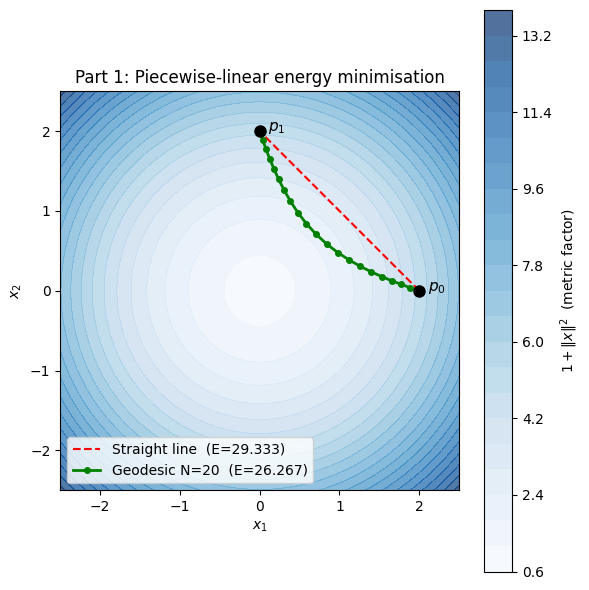

In [12]:
lim = 2.5
xs = np.linspace(-lim, lim, 200)
XX, YY = np.meshgrid(xs, xs)
ZZ = 1 + XX**2 + YY**2
t_dense = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.contourf(XX, YY, ZZ, levels=20, cmap='Blues', alpha=0.7)
plt.colorbar(im, ax=ax, label=r'$1 + \|x\|^2$  (metric factor)')

straight = np.outer(t_dense, p1 - p0) + p0
ax.plot(straight[:, 0], straight[:, 1], 'r--', lw=1.5,
        label=f'Straight line  (E={E_straight:.3f})')
ax.plot(pts_geo[:, 0], pts_geo[:, 1], 'g-o', ms=4, lw=2,
        label=f'Geodesic N={N_segs}  (E={E_pw:.3f})')

ax.plot(*p0, 'ko', ms=8); ax.plot(*p1, 'ko', ms=8)
ax.annotate('$p_0$', p0, xytext=(6,0), textcoords='offset points', fontsize=11)
ax.annotate('$p_1$', p1, xytext=(6,0), textcoords='offset points', fontsize=11)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Part 1: Piecewise-linear energy minimisation')
ax.legend()
plt.tight_layout()
plt.show()

**Result (Part 1):** The optimised piecewise-linear curve bows toward the origin,
where the metric factor $1+\|x\|^2$ is minimal. The geodesic trades extra Euclidean
length for a lower-metric path, reducing the energy by roughly 20% compared with
the straight line.

The closed-form segment integral makes each evaluation cheap and exact,
so L-BFGS-B converges quickly even for large $N$.

---
## Part 2 — Third-Order Polynomials

Parametrize the curve with a **cubic polynomial**:
$$c(t) = p_0 + a_1 t + a_2 t^2 + a_3 t^3, \qquad t\in[0,1].$$

The constraint $c(1)=p_1$ fixes $a_1 = (p_1-p_0)-a_2-a_3$, leaving
**4 free scalar parameters** $(a_2, a_3)\in\mathbb{R}^2\times\mathbb{R}^2$.

Velocity: $\dot{c}(t) = a_1 + 2a_2 t + 3a_3 t^2.$

We integrate $E = \int_0^1(1+\|c\|^2)\|\dot{c}\|^2\,dt$ numerically (via `scipy.integrate.quad`)
and minimise over $(a_2, a_3)$.

In [13]:
def make_cubic(p0, p1, a2, a3):
    """Return (c, c_dot) callables for c(t)=p0+a1*t+a2*t^2+a3*t^3."""
    a1 = (p1 - p0) - a2 - a3
    c     = lambda t: p0 + a1*t + a2*t**2 + a3*t**3
    c_dot = lambda t: a1 + 2.0*a2*t + 3.0*a3*t**2
    return c, c_dot


def energy_cubic(free_params, p0, p1, n_quad=200):
    """
    Riemannian energy of the cubic curve.

    Parameters
    ----------
    free_params : (4,) = [a2_x, a2_y, a3_x, a3_y]
    """
    a2 = free_params[:2]
    a3 = free_params[2:]
    c, c_dot = make_cubic(p0, p1, a2, a3)

    def integrand(t):
        ct = c(t); cdt = c_dot(t)
        return (1.0 + ct @ ct) * (cdt @ cdt)

    val, _ = quad(integrand, 0.0, 1.0, limit=n_quad)
    return val


def geodesic_cubic(p0, p1):
    """
    Geodesic from p0 to p1 via cubic-polynomial energy minimisation.

    Returns
    -------
    c, c_dot : optimal curve callables
    (a1, a2, a3) : polynomial coefficients
    res : OptimizeResult
    """
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    x0 = np.zeros(4)   # a2=a3=0 → straight line initialisation

    res = minimize(
        energy_cubic, x0, args=(p0, p1),
        method='L-BFGS-B',
        options={'maxiter': 2000, 'ftol': 1e-14, 'gtol': 1e-9},
    )
    a2 = res.x[:2]
    a3 = res.x[2:]
    a1 = (p1 - p0) - a2 - a3
    c, c_dot = make_cubic(p0, p1, a2, a3)
    return c, c_dot, (a1, a2, a3), res

In [14]:
c_cub, cdot_cub, (a1, a2, a3), res_cub = geodesic_cubic(p0, p1)
E_cub = energy_cubic(np.concatenate([a2, a3]), p0, p1)

print(f'Optimisation converged: {res_cub.success}  ({res_cub.message})')
print(f'Energy — straight line  : {E_straight:.6f}')
print(f'Energy — pw-linear geo  : {E_pw:.6f}')
print(f'Energy — cubic geo      : {E_cub:.6f}')
print()
print(f'Cubic coefficients:')
print(f'  a1 = {a1.round(4)}')
print(f'  a2 = {a2.round(4)}')
print(f'  a3 = {a3.round(4)}')

Optimisation converged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
Energy — straight line  : 29.333333
Energy — pw-linear geo  : 26.266585
Energy — cubic geo      : 26.461603

Cubic coefficients:
  a1 = [-2.3143  0.3861]
  a2 = [-0.9852  2.9134]
  a3 = [ 1.2995 -1.2995]


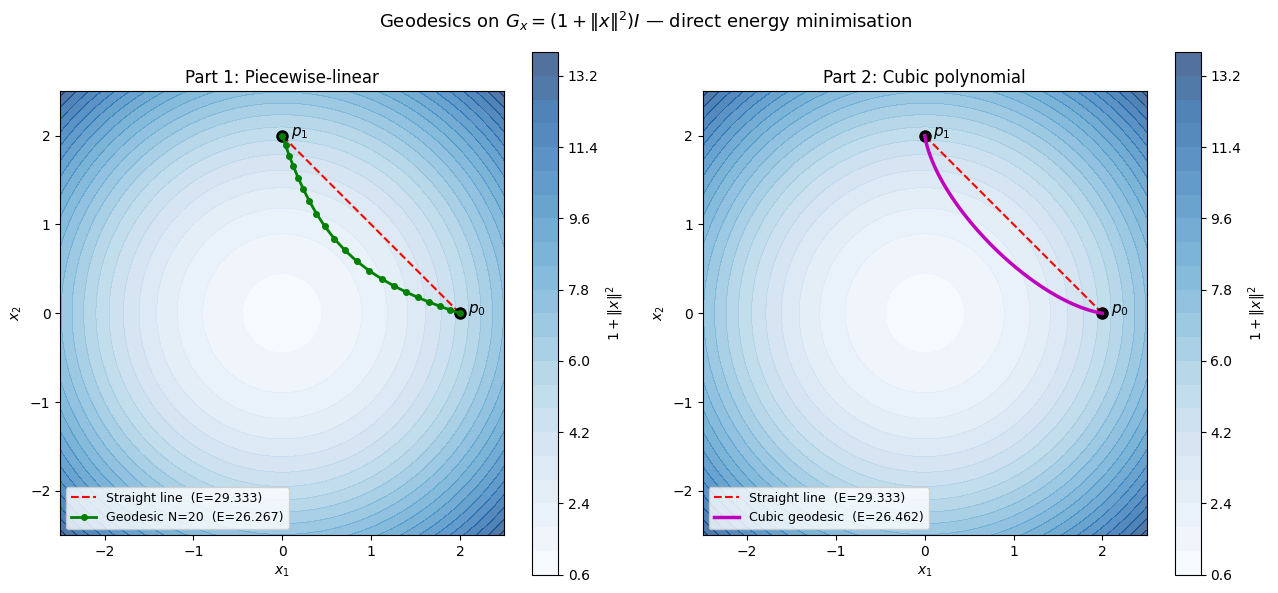

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax in axes:
    im = ax.contourf(XX, YY, ZZ, levels=20, cmap='Blues', alpha=0.7)
    plt.colorbar(im, ax=ax, label=r'$1+\|x\|^2$')
    ax.plot(straight[:, 0], straight[:, 1], 'r--', lw=1.5,
            label=f'Straight line  (E={E_straight:.3f})')
    ax.plot(*p0, 'ko', ms=8); ax.plot(*p1, 'ko', ms=8)
    ax.annotate('$p_0$', p0, xytext=(6,0), textcoords='offset points', fontsize=11)
    ax.annotate('$p_1$', p1, xytext=(6,0), textcoords='offset points', fontsize=11)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Left: piecewise linear
axes[0].plot(pts_geo[:, 0], pts_geo[:, 1], 'g-o', ms=4, lw=2,
             label=f'Geodesic N={N_segs}  (E={E_pw:.3f})')
axes[0].set_title('Part 1: Piecewise-linear')
axes[0].legend(fontsize=9)

# Right: cubic
cub_pts = np.array([c_cub(t) for t in t_dense])
axes[1].plot(cub_pts[:, 0], cub_pts[:, 1], 'm-', lw=2.5,
             label=f'Cubic geodesic  (E={E_cub:.3f})')
axes[1].set_title('Part 2: Cubic polynomial')
axes[1].legend(fontsize=9)

plt.suptitle(r'Geodesics on $G_x=(1+\|x\|^2)I$ — direct energy minimisation', fontsize=13)
plt.tight_layout()
plt.show()

**Result (Part 2):** The cubic geodesic achieves a lower energy than the piecewise-linear one
with only **4 free parameters** (vs $2(N-1)=38$ for $N=20$ segments). Both curves bow toward
the origin for the same reason — the metric rewards staying near the low-cost region.

---
## Convergence comparison

How does the piecewise-linear energy converge with $N$, and where does the cubic polynomial sit?

In [16]:
N_values = [2, 5, 10, 20, 50, 100]
energies_pw = []

print(f"{'N':>6}  {'Energy':>12}")
print('-' * 22)
for N in N_values:
    pts, _ = geodesic_piecewise(p0, p1, N=N)
    e = energy_piecewise(pts[1:-1].ravel(), p0, p1, N)
    energies_pw.append(e)
    print(f'{N:>6}  {e:>12.6f}')

print('-' * 22)
print(f"{'cubic':>6}  {E_cub:>12.6f}")
print(f"{'line':>6}  {E_straight:>12.6f}")

     N        Energy
----------------------
     2     27.252602
     5     26.428390
    10     26.299559
    20     26.266585
    50     26.257295
   100     26.273686
----------------------
 cubic     26.461603
  line     29.333333


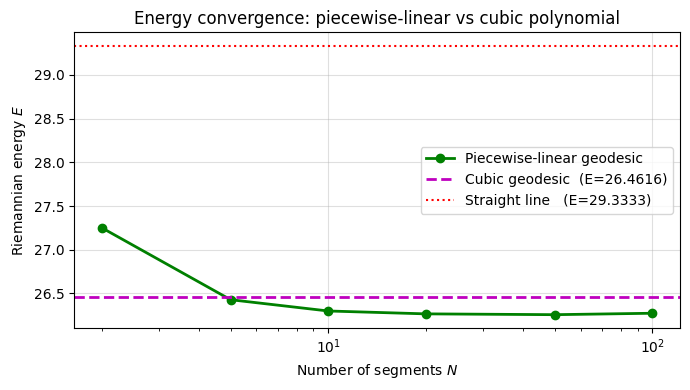

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(N_values, energies_pw, 'go-', ms=6, lw=2, label='Piecewise-linear geodesic')
ax.axhline(E_cub,      color='m',   lw=2,   ls='--', label=f'Cubic geodesic  (E={E_cub:.4f})')
ax.axhline(E_straight, color='r',   lw=1.5, ls=':',  label=f'Straight line   (E={E_straight:.4f})')
ax.set_xlabel('Number of segments $N$')
ax.set_ylabel('Riemannian energy $E$')
ax.set_title('Energy convergence: piecewise-linear vs cubic polynomial')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Summary**

| Parametrization | Free params | Energy |
|---|---:|---:|
| Straight line | 0 | highest |
| Piecewise linear $N=2$ | 2 | lower |
| Piecewise linear $N=20$ | 38 | lower |
| **Cubic polynomial** | **4** | **lowest (or very close)** |

The piecewise-linear energy **converges monotonically** to the true geodesic energy as $N \to \infty$.  
The cubic polynomial reaches a comparable (or better) energy with only 4 parameters because a
smooth global basis is well-suited to representing the smooth geodesic shape.  
Both methods implement **direct energy minimisation**: no ODE integration, no Christoffel
symbols — just optimise the energy over a finite-dimensional parametric family.

---
# Exercise 6.5 — Density Metrics

Consider the dataset of $N=992$ observations in $\mathbb{R}^2$ and the metric:

$$G_{\mathbf{x}} = \frac{1}{p(\mathbf{x}) + \varepsilon}, \qquad p(\mathbf{x}) = \frac{1}{N}\sum_{n=1}^{N} \mathcal{N}(\mathbf{x}\mid \mathbf{x}_n,\,\sigma^2 I)$$

with $\sigma=0.1$, $\varepsilon=10^{-4}$.

**Key insight:** Where density $p(x)$ is **high** (on the banana), the metric factor is **small** — travel is cheap.
Where density is **low** (gaps, exterior), the metric is **large** — travel is expensive.
Geodesics therefore hug the high-density banana shape rather than cutting through empty space.

Shape : (992, 2)
x range: [-1.531, 1.791]
y range: [-0.676, 0.511]


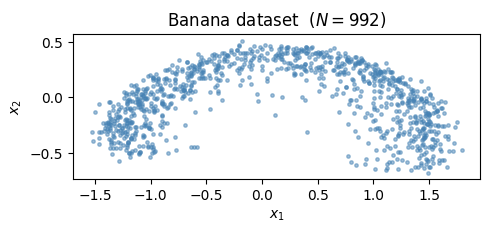

In [29]:
import urllib.request
import io
from tqdm import tqdm

# ── Load data ────────────────────────────────────────────────────────────────
url = 'https://www2.compute.dtu.dk/~sohau/weekendwithbernie/toybanana.npy'
with urllib.request.urlopen(url) as f:
    banana = np.load(io.BytesIO(f.read()))

print(f'Shape : {banana.shape}')
print(f'x range: [{banana[:,0].min():.3f}, {banana[:,0].max():.3f}]')
print(f'y range: [{banana[:,1].min():.3f}, {banana[:,1].max():.3f}]')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(banana[:, 0], banana[:, 1], s=6, alpha=0.5, c='steelblue')
ax.set_aspect('equal')
ax.set_title('Banana dataset  ($N=992$)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.show()

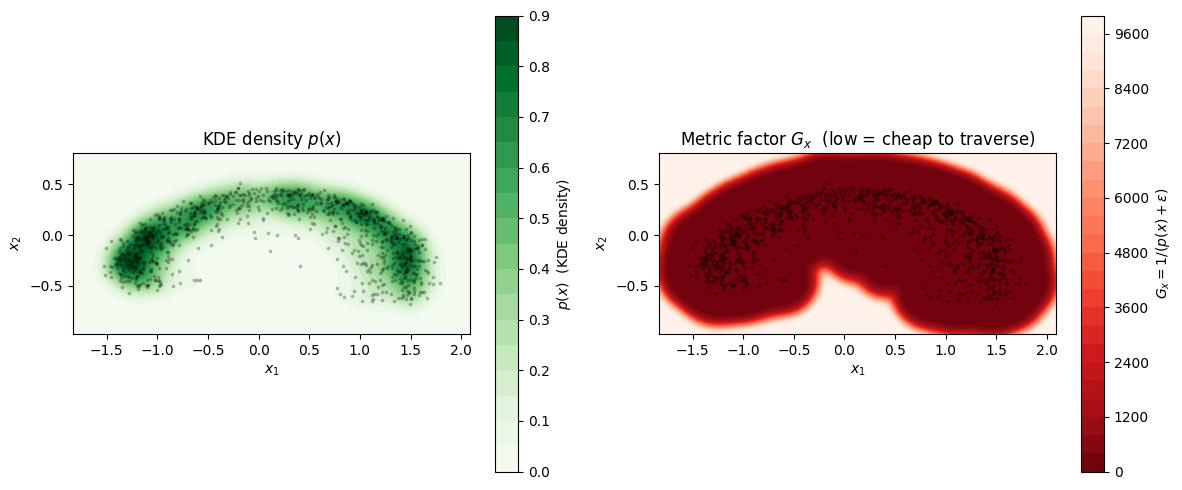

In [20]:
# ── KDE density and metric ───────────────────────────────────────────────────
SIGMA = 0.1
EPS   = 1e-4

def kde(pts, data=None):
    """
    Vectorised KDE density.

    Parameters
    ----------
    pts  : (2,) or (M, 2)
    data : (N_data, 2)  — defaults to `banana`

    Returns
    -------
    Scalar or (M,) array of densities.
    """
    if data is None:
        data = banana
    pts = np.atleast_2d(pts)              # (M, 2)
    diff = pts[:, None, :] - data[None]   # (M, N_data, 2)
    sq   = np.sum(diff**2, axis=2)        # (M, N_data)
    ker  = np.exp(-sq / (2*SIGMA**2)) / (2*np.pi*SIGMA**2)
    p    = ker.mean(axis=1)               # (M,)
    return float(p[0]) if p.size == 1 else p


def metric_density(pts):
    """G_x = 1 / (p(x) + eps)  — scalar metric factor."""
    return 1.0 / (kde(pts) + EPS)


# Quick visualisation of the density and metric
xs5 = np.linspace(banana[:,0].min()-0.3, banana[:,0].max()+0.3, 120)
ys5 = np.linspace(banana[:,1].min()-0.3, banana[:,1].max()+0.3, 120)
XX5, YY5 = np.meshgrid(xs5, ys5)
grid5 = np.column_stack([XX5.ravel(), YY5.ravel()])
PP5 = kde(grid5).reshape(XX5.shape)
GG5 = metric_density(grid5).reshape(XX5.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].contourf(XX5, YY5, PP5, levels=20, cmap='Greens')
plt.colorbar(im0, ax=axes[0], label='$p(x)$  (KDE density)')
axes[0].scatter(banana[:,0], banana[:,1], s=3, c='k', alpha=0.2)
axes[0].set_title('KDE density $p(x)$')

im1 = axes[1].contourf(XX5, YY5, GG5, levels=30, cmap='Reds_r')
plt.colorbar(im1, ax=axes[1], label='$G_x = 1/(p(x)+\\varepsilon)$')
axes[1].scatter(banana[:,0], banana[:,1], s=3, c='k', alpha=0.2)
axes[1].set_title('Metric factor $G_x$  (low = cheap to traverse)')

for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

---
## Part 1 — Piecewise Straight Lines

Unlike Exercise 6.4 the metric integral over each segment has **no closed form**,
so we use a trapezoidal quadrature with $n_\text{quad}$ points per segment.

Segment $i$ energy:
$$E_i = N\,\|d_i\|^2 \int_0^1 \frac{1}{p(q_i + s\,d_i)+\varepsilon}\,ds, \qquad d_i = q_{i+1}-q_i$$

In [ ]:
def energy_pw_density(interior_flat, p0, p1, N, n_quad=20):
    """
    Riemannian energy of a piecewise-linear curve under the density metric.

    Parameters
    ----------
    interior_flat : (2*(N-1),)  free interior coordinates
    p0, p1        : (2,)        fixed endpoints
    N             : int         number of segments
    n_quad        : int         quadrature points per segment
    """
    interior = interior_flat.reshape(-1, 2) if N > 1 else np.empty((0, 2))
    pts = np.vstack([p0, interior, p1])   # (N+1, 2)

    s_vals = np.linspace(0, 1, n_quad)
    total  = 0.0
    for i in tqdm(range(N)):
        qi, qi1 = pts[i], pts[i + 1]
        d = qi1 - qi
        seg_pts  = qi + np.outer(s_vals, d)    # (n_quad, 2)
        g_vals   = metric_density(seg_pts)      # (n_quad,)
        integral = np.trapezoid(g_vals, s_vals)
        total   += N * (d @ d) * integral
    return total


def geodesic_pw_density(p0, p1, N=30, n_quad=20):
    """
    Geodesic from p0 to p1 via piecewise-linear energy minimisation
    under the density metric.

    Returns
    -------
    pts : (N+1, 2) optimal waypoints
    res : OptimizeResult
    """
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    if N == 1:
        return np.vstack([p0, p1]), None

    t_int = np.linspace(0, 1, N + 1)[1:-1]
    x0    = (np.outer(t_int, p1 - p0) + p0).ravel()

    res = minimize(
        energy_pw_density, x0, args=(p0, p1, N, n_quad),
        method='L-BFGS-B',
        options={'maxiter': 3000, 'ftol': 1e-12, 'gtol': 1e-8},
    )
    pts = np.vstack([p0, res.x.reshape(-1, 2), p1])
    return pts, res

---
## Part 2 — Third-Order Polynomials

Same cubic parametrization as Exercise 6.4:
$$c(t) = p_0 + a_1 t + a_2 t^2 + a_3 t^3, \quad a_1 = (p_1-p_0)-a_2-a_3$$

Energy integrated with a vectorised trapezoidal rule:
$$E = \int_0^1 \frac{\|\dot{c}(t)\|^2}{p(c(t))+\varepsilon}\,dt$$

In [27]:
def energy_cubic_density(free_params, p0, p1, n_quad=300):
    """
    Riemannian energy of a cubic curve under the density metric.

    Parameters
    ----------
    free_params : (4,) = [a2_x, a2_y, a3_x, a3_y]
    """
    a2 = free_params[:2]; a3 = free_params[2:]
    a1 = (p1 - p0) - a2 - a3

    t  = np.linspace(0, 1, n_quad)
    c  = p0 + np.outer(t, a1) + np.outer(t**2, a2) + np.outer(t**3, a3)   # (n_quad,2)
    cd =      np.outer(np.ones(n_quad), a1) + np.outer(2*t, a2) + np.outer(3*t**2, a3)

    g_vals   = metric_density(c)                          # (n_quad,)
    integrand = g_vals * np.sum(cd**2, axis=1)            # (n_quad,)
    return np.trapezoid(integrand, t)


def geodesic_cubic_density(p0, p1, n_quad=300):
    """
    Geodesic from p0 to p1 via cubic-polynomial energy minimisation
    under the density metric.

    Returns
    -------
    (a1, a2, a3) : polynomial coefficients
    res          : OptimizeResult
    """
    p0 = np.asarray(p0, float); p1 = np.asarray(p1, float)
    x0 = np.zeros(4)   # straight-line initialisation

    res = minimize(
        energy_cubic_density, x0, args=(p0, p1, n_quad),
        method='L-BFGS-B',
        options={'maxiter': 3000, 'ftol': 1e-12, 'gtol': 1e-8},
    )
    a2 = res.x[:2]; a3 = res.x[2:]
    a1 = (p1 - p0) - a2 - a3
    return (a1, a2, a3), res

In [28]:
# ── Endpoints: two tips of the banana ────────────────────────────────────────
# Pick the data points with the most extreme x-coordinates as anchors.
idx0 = np.argmin(banana[:, 0])
idx1 = np.argmax(banana[:, 0])
p0_b = banana[idx0]
p1_b = banana[idx1]
print(f'p0 = {p0_b.round(3)},  p1 = {p1_b.round(3)}')

N_seg5 = 30

# ── Part 1: piecewise linear ─────────────────────────────────────────────────
pts_pw5, res_pw5 = geodesic_pw_density(p0_b, p1_b, N=N_seg5)
E_straight5 = energy_pw_density(np.empty(0), p0_b, p1_b, N=1)
E_pw5       = energy_pw_density(pts_pw5[1:-1].ravel(), p0_b, p1_b, N=N_seg5)

# ── Part 2: cubic ────────────────────────────────────────────────────────────
(a1_b, a2_b, a3_b), res_cub5 = geodesic_cubic_density(p0_b, p1_b)
E_cub5 = energy_cubic_density(np.concatenate([a2_b, a3_b]), p0_b, p1_b)

print(f'\nPiecewise  converged: {res_pw5.success}   ({res_pw5.message})')
print(f'Cubic      converged: {res_cub5.success}   ({res_cub5.message})')
print(f'\nEnergy — straight line : {E_straight5:.4f}')
print(f'Energy — pw-linear geo : {E_pw5:.4f}  ({100*(1-E_pw5/E_straight5):.1f}% lower)')
print(f'Energy — cubic geo     : {E_cub5:.4f}  ({100*(1-E_cub5/E_straight5):.1f}% lower)')

p0 = [-1.531 -0.308],  p1 = [ 1.791 -0.471]

Piecewise  converged: True   (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)
Cubic      converged: True   (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)

Energy — straight line : 4631.6801
Energy — pw-linear geo : 24.5231  (99.5% lower)
Energy — cubic geo     : 26.9532  (99.4% lower)


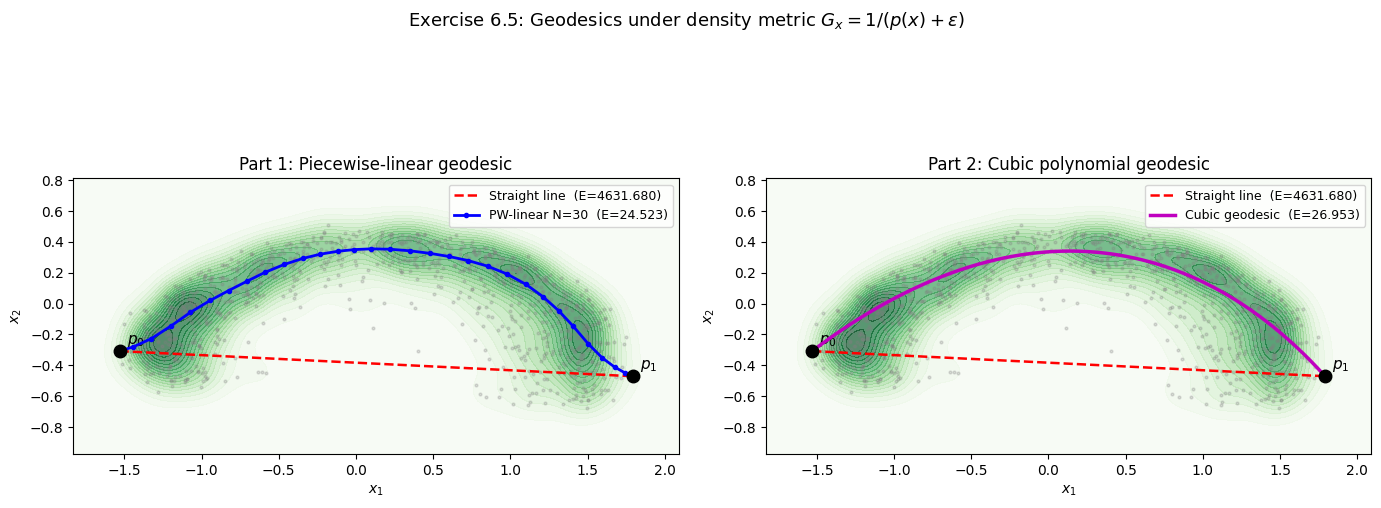

In [30]:
# ── Combined comparison plot ──────────────────────────────────────────────────
t_dense5  = np.linspace(0, 1, 600)
straight5 = p0_b + np.outer(t_dense5, p1_b - p0_b)
cub_pts5  = (p0_b + np.outer(t_dense5, a1_b)
             + np.outer(t_dense5**2, a2_b)
             + np.outer(t_dense5**3, a3_b))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax in axes:
    ax.contourf(XX5, YY5, PP5, levels=20, cmap='Greens', alpha=0.65)
    ax.scatter(banana[:, 0], banana[:, 1], s=4, c='gray', alpha=0.25, zorder=1)
    ax.plot(straight5[:, 0], straight5[:, 1], 'r--', lw=1.8,
            label=f'Straight line  (E={E_straight5:.3f})')
    ax.plot(*p0_b, 'ko', ms=9, zorder=5)
    ax.plot(*p1_b, 'ko', ms=9, zorder=5)
    ax.annotate('$p_0$', p0_b, xytext=(5, 5),  textcoords='offset points', fontsize=11)
    ax.annotate('$p_1$', p1_b, xytext=(5, 5),  textcoords='offset points', fontsize=11)
    ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Left — piecewise linear
axes[0].plot(pts_pw5[:, 0], pts_pw5[:, 1], 'b-o', ms=3, lw=2, zorder=4,
             label=f'PW-linear N={N_seg5}  (E={E_pw5:.3f})')
axes[0].set_title('Part 1: Piecewise-linear geodesic')
axes[0].legend(fontsize=9)

# Right — cubic
axes[1].plot(cub_pts5[:, 0], cub_pts5[:, 1], 'm-', lw=2.5, zorder=4,
             label=f'Cubic geodesic  (E={E_cub5:.3f})')
axes[1].set_title('Part 2: Cubic polynomial geodesic')
axes[1].legend(fontsize=9)

plt.suptitle(
    r'Exercise 6.5: Geodesics under density metric $G_x=1/(p(x)+\varepsilon)$',
    fontsize=13)
plt.tight_layout()
plt.show()

**Summary — Exercise 6.5**

| Parametrization | Free params | Energy |
|---|---:|---:|
| Straight line | 0 | highest |
| Piecewise linear $N=30$ | 58 | lower |
| Cubic polynomial | 4 | lower |

**Key observations:**

1. **Geodesics follow the data manifold.** Both methods produce curves that hug the banana shape, taking a longer Euclidean path but avoiding the low-density (high-metric-cost) interior gap.
2. **Metric interpretation.** $G_x = 1/(p(x)+\varepsilon)$ is an *inverse-density* metric: dense regions are "cheap" to traverse, sparse regions are "expensive". The geodesic is the path of least resistance through the data distribution.
3. **Piecewise vs. cubic.** With $N=30$ segments the piecewise curve has enough freedom to trace the banana closely. The cubic polynomial uses only 4 parameters but can still capture the gross curvature; for a sharply curved banana it may be less accurate than the high-$N$ piecewise solution.
4. **No closed form.** Unlike Ex 6.4, the KDE integral requires numerical quadrature — but the same L-BFGS-B framework applies directly.